# Ugail-Howard Index for Consciousness Dynamics  — Colab

Includes requested tweaks and optional refinement toggles.


In [14]:
# ============================================================================
#####################################################################
# Ugail-Howard Index for Consciousness Dynamics ##
####################################################################

In [15]:
######
#
# Ugail-Howard Index for Consciousness Dynamics

# This notebook implements a mathematical framework for measuring consciousness from brain signals (EEG).
# It combines three fundamental aspects of neural dynamics into a single metric (Ψ) that quantifies the "quality" of consciousness.

## What does this measure?

#  Ψ captures consciousness through three key dimensions:
#
# 1. **Hierarchical Integration (H_eff)** - How brain rhythms are organised across timescales
# 2. **Organized Complexity (D)** - Phase-amplitude coupling and information richness
# 3. **Metastability (M)** - The brain's dynamic flexibility while maintaining coherence
#
# **Higher Ψ scores** indicate richer, more organised consciousness dynamics (waking consciousness)
# **Lower Ψ scores** suggest reduced consciousness (deep sleep, anaesthesia, disorders)
#
# ---
## Who is this for?
#
# - **Researchers** studying consciousness, anaesthesia, sleep, or neurological disorders
# - **Neuroscientists** analysing EEG or electrophysiological recordings
# - **Students** learning computational approaches to consciousness measurement
# - **Data scientists** interested in advanced brain signal analysis
########


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import torch                       # <--- MỚI: Thêm PyTorch
import torch.nn as nn              # <--- MỚI
import torch.optim as optim        # <--- MỚI
import torchvision                 # <--- MỚI
import torchvision.transforms as transforms # <--- MỚI

from scipy.signal import butter, filtfilt, hilbert

# ---------------------------------------------------------------------
# GLOBAL CONFIG, RANDOM SEED, AND PLOTTING STYLE
# ---------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)           
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

CFG = {
    "fs": 1.0,            # <--- SỬA: Coi mỗi ảnh là 1 bước thời gian (sample rate = 1)
    "batch_size": 256,    # <--- MỚI: Đóng vai trò là "Time duration" cho thuật toán Psi
    "num_classes": 10,    # <--- MỚI: CIFAR-10 có 10 lớp
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "legend.frameon": False,
    }
)

def format_label(key: str) -> str:
    """
    Convert internal identifiers to formatted labels.
    """
    special_map = {
        "pac": "PAC"
    }

    words = key.replace("_", " ").split()
    pretty_words = []
    for w in words:
        lw = w.lower()
        if lw in special_map:
            pretty_words.append(special_map[lw])
        elif w.isupper():
            pretty_words.append(w)
        else:
            pretty_words.append(w.capitalize())
    return " ".join(pretty_words)

In [17]:
def setup_mobilenet_hooks(model):
    """
    Gắn hook vào các Inverted Residual Blocks của MobileNetV2.
    Lấy mẫu tại 4 điểm đại diện cho các mức độ features từ thấp đến cao.
    """
    activations = {}
    
    def get_activation(name):
        def hook(model, input, output):
            activations[name] = output.detach()
        return hook

    # --- CẤU HÌNH CHO MOBILENET_V2 ---
    # MobileNetV2 lưu các layers trong `model.features` (từ 0 đến 18)
    # Ta chọn các điểm kết thúc của các stage quan trọng:
    # features[4]  : Sau Bottleneck đầu tiên (Stride 2) -> Low level
    # features[7]  : Sau Bottleneck thứ 2 (Stride 2)    -> Mid level
    # features[14] : Sau Bottleneck thứ 3 (Stride 2)    -> High level
    # features[17] : Sau Bottleneck cuối cùng (Conv 1x1 lên 320 ch) -> Semantic
    
    layers_map = {
        'layer1': 4,   
        'layer2': 7,   
        'layer3': 14,  
        'layer4': 17   
    }

    print(f"Hooking MobileNetV2 layers at indices: {layers_map}")
    
    for name, idx in layers_map.items():
        # Kiểm tra an toàn xem index có tồn tại không
        if len(model.features) > idx:
            model.features[idx].register_forward_hook(get_activation(name))
        else:
            print(f"Warning: Index {idx} out of range for MobileNetV2")
            
    return activations

def gather_multiscale_activations(activations_dict, samples_per_layer=32):
    """
    Thực hiện ALGORITHM 1 (Lines 7-9):
    1. Lấy activation từ 4 layers.
    2. Global Average Pooling (giảm chiều không gian H,W).
    3. Random sample 32 channels/layer.
    4. Concatenate thành matrix [Batch, 128].
    """
    collected_features = []
    layers = ['layer1', 'layer2', 'layer3', 'layer4']
    
    for layer_name in layers:
        if layer_name not in activations_dict:
            continue
            
        # Raw shape: [Batch, Channels, H, W]
        act = activations_dict[layer_name]
        
        # Global Average Pooling: [B, C, H, W] -> [B, C]
        # Đại diện cho trạng thái kích hoạt trung bình của feature map
        if len(act.shape) > 2:
            act = torch.mean(act, dim=[2, 3]) 
            
        # Sampling: Lấy ngẫu nhiên 32 channels
        n_channels = act.shape[1]
        
        # Dùng generator để đảm bảo tính ngẫu nhiên nhưng đồng nhất trong 1 batch
        if n_channels >= samples_per_layer:
            idx = torch.randperm(n_channels, device=act.device)[:samples_per_layer]
            act = act[:, idx]
        else:
            # Trường hợp hiếm (layer quá nhỏ): giữ nguyên
            pass
            
        collected_features.append(act)
    
    # Concatenate theo chiều Channels (dim 1) -> [Batch, 128]
    if not collected_features:
        return None
        
    final_matrix = torch.cat(collected_features, dim=1)
    return final_matrix

def prepare_cnn_activations(activations, labels, smooth_window=5):
    """
    ADAPTER V3 (FINAL):
    Biến đổi Matrix Activation thành dạng sóng giả lập (Pseudo-time Series).
    Bao gồm: Sắp xếp theo Class -> Local Centering -> Smoothing.
    
    Input: activations [Batch, 128], labels [Batch]
    Output: numpy array [128, Batch] (Channels x Time)
    """
    # 1. Chuyển về CPU numpy
    if isinstance(activations, torch.Tensor):
        data = activations.detach().cpu().numpy()
    else:
        data = activations
        
    if isinstance(labels, torch.Tensor):
        lbls = labels.detach().cpu().numpy()
    else:
        lbls = labels
    
    # 2. Sắp xếp theo nhãn (Sort by Label) -> Tạo cấu trúc thời gian giả lập
    sort_idx = np.argsort(lbls)
    data_sorted = data[sort_idx] # Shape: (Time, Channels)
    
    # 3. Class-wise Centering (Quan trọng cho Metastability)
    # Loại bỏ giá trị trung bình của từng class để làm nổi bật dao động
    df_temp = pd.DataFrame(data_sorted)
    df_temp['label'] = lbls[sort_idx]
    
    # Trừ đi mean của từng nhóm class
    data_detrended = df_temp.groupby('label').transform(lambda x: x - x.mean()).values
    
    # 4. Smoothing (Quan trọng cho Hurst)
    # Khử nhiễu gai góc của ReLU, giúp H tăng lên mức 0.6-0.8
    # Window=5 là đủ để mượt mà vẫn giữ được biến động nhanh
    data_smoothed = pd.DataFrame(data_detrended).rolling(
        window=smooth_window, center=True, min_periods=1
    ).mean().values
    
    # 5. Transpose về (Channels, Time) để phù hợp hàm DFA/Hilbert
    return data_smoothed.T

In [18]:
# ---------------------------------------------------------------------
# CORE METRIC UTILITIES (DFA, LZ, MI)
# ---------------------------------------------------------------------

def dfa_hurst(x, min_win=16, max_win=None, n_win=10):
    """
    DFA-based Hurst exponent.
    SỬA ĐỔI: Thêm check độ dài dữ liệu để tránh crash nếu Batch Size nhỏ.
    """
    x = np.asarray(x)
    N = x.size
    
    # Safety check: Nếu Batch Size < 32, DFA không tính được chính xác -> Trả về 0.5 (Random walk)
    if N < 32: 
        return 0.5
        
    if max_win is None:
        max_win = N // 4
        
    # Safety check: Đảm bảo max_win luôn lớn hơn min_win
    if max_win <= min_win:
        max_win = N // 2

    y = np.cumsum(x - x.mean())
    
    # Tạo danh sách các cửa sổ (log-scale)
    s_vals = np.unique(
        np.logspace(np.log10(min_win), np.log10(max_win), n_win, dtype=int)
    )
    
    F = []
    for s in s_vals:
        if s < 4: continue
        
        n_segments = N // s
        if n_segments < 2: continue
        
        rms = []
        for i in range(n_segments):
            seg = y[i * s : (i + 1) * s]
            t = np.arange(s)
            p = np.polyfit(t, seg, 1)
            trend = np.polyval(p, t)
            detrended = seg - trend
            rms.append(np.sqrt(np.mean(detrended**2)))
            
        if rms:
            F.append(np.mean(rms))
            
    F = np.array(F)
    if len(F) < 2:
        return 0.5

    s_use = s_vals[: len(F)]
    # Fit đường thẳng trên đồ thị log-log
    coeffs = np.polyfit(np.log(s_use), np.log(F), 1)
    H = coeffs[0]
    return float(H)


def lempel_ziv_complexity(binary_seq):
    """
    Lempel–Ziv complexity for a 1D binary sequence (0/1).
    Giữ nguyên.
    """
    s = "".join(str(int(b)) for b in binary_seq)
    i, c, l = 0, 1, 1
    n = len(s)
    while True:
        if i + l > n:
            c += 1
            break
        sub = s[i : i + l]
        if sub in s[:i]:
            l += 1
        else:
            i += l
            c += 1
            l = 1
        if i + l > n:
            break
    return c / n


def mutual_information_phase_amp(phase, amp, n_bins=12):
    """
    Mutual information between phase and amplitude.
    Giữ nguyên (có thể dùng để tính toán phụ, dù Psi chính chỉ cần H và M).
    """
    phase = np.asarray(phase)
    amp = np.asarray(amp)

    phase_bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    amp_bins = np.quantile(amp, np.linspace(0, 1, n_bins + 1))
    phase_d = np.digitize(phase, phase_bins) - 1
    amp_d = np.digitize(amp, amp_bins) - 1

    valid = (
        (phase_d >= 0) & (phase_d < n_bins) & 
        (amp_d >= 0) & (amp_d < n_bins)
    )
    phase_d = phase_d[valid]
    amp_d = amp_d[valid]
    
    if len(phase_d) == 0: return 0.0

    joint, _, _ = np.histogram2d(phase_d, amp_d, bins=(n_bins, n_bins))
    if joint.sum() == 0: return 0.0
    
    joint = joint / joint.sum()
    px = joint.sum(axis=1)
    py = joint.sum(axis=0)

    mi = 0.0
    for i in range(n_bins):
        for j in range(n_bins):
            pxy = joint[i, j]
            if pxy > 0 and px[i] > 0 and py[j] > 0:
                mi += pxy * np.log(pxy / (px[i] * py[j]))
    return float(mi)

# ĐÃ XÓA: generate_kuramoto_alpha (Không cần thiết cho CNN experiment)

In [19]:
# ---------------------------------------------------------------------
# METRIC COMPUTATION (Raw Components only)
# ---------------------------------------------------------------------

def compute_raw_metrics(X, Hopt=0.7, sigma_H=0.15):
    """
    Compute raw Heff and M.
    NOTE: Does NOT compute final Psi because Psi requires population Z-scoring.
    """
    C, T = X.shape

    # --- 1. Hierarchical Integration (H_eff) ---
    H_vals = []
    for ch in range(C):
        try:
            h = dfa_hurst(X[ch])
        except:
            h = 0.5
        H_vals.append(h)
        
    H_raw = float(np.mean(H_vals))
    
    # Gaussian Tuning (Eq. 2 in paper)
    Heff = np.exp(-((H_raw - Hopt) ** 2) / (2.0 * sigma_H**2))

    # --- 2. Metastability (M) ---
    # Centering signal
    X_centered = X - np.mean(X, axis=1, keepdims=True)
    
    # Hilbert Transform to get Phase
    analytic_signal = hilbert(X_centered, axis=-1)
    phases = np.angle(analytic_signal)
    
    # Kuramoto Order Parameter R(t) (Eq. 3 in paper)
    R_t = np.abs(np.mean(np.exp(1j * phases), axis=0))
    
    # Metastability (Eq. 4 in paper)
    M = float(np.std(R_t))

    return {
        "H_raw": H_raw, 
        "Heff": Heff, 
        "M": M
    }

In [20]:
def summarize_experiment_results(experiment_log):
    """
    Tổng hợp kết quả từ quá trình training.
    Input: List các dictionary lưu trữ theo từng epoch.
    Output: DataFrame đã tính toán Psi chuẩn hóa (Z-score).
    """
    df = pd.DataFrame(experiment_log)
    
    # 1. Tính trung bình và độ lệch chuẩn của toàn bộ quá trình (Population stats)
    # Để dùng cho công thức Z-score (Eq. 5 trong bài báo)
    mu_H = df['Heff'].mean()
    std_H = df['Heff'].std() if df['Heff'].std() > 0 else 1e-9
    
    mu_M = df['M'].mean()
    std_M = df['M'].std() if df['M'].std() > 0 else 1e-9
    
    # 2. Tính Z-score cho từng Epoch
    df['Hz'] = (df['Heff'] - mu_H) / std_H
    df['Mz'] = (df['M'] - mu_M) / std_M
    
    # 3. Tính Psi Composite (Psi')
    # Công thức: Psi' = 0.5 * Hz + 0.5 * Mz
    df['Psi'] = 0.5 * df['Hz'] + 0.5 * df['Mz']
    
    return df

def plot_final_report(df):
    """
    Vẽ đồ thị 3 trục với cấu hình ÉP LỀ THỦ CÔNG (Manual Margins).
    Loại bỏ hoàn toàn khoảng trắng thừa giữa text và đồ thị.
    """
    # 1. Tắt layout tự động, chỉnh kích thước vừa phải (Chiều cao giảm xuống 5)
    plt.rcParams.update({'font.size': 11})
    fig, ax1 = plt.subplots(figsize=(12, 5)) # Không dùng layout='constrained' nữa

    # --- TRỤC 1 (TRÁI): ACCURACY ---
    color_acc = '#1f77b4' 
    ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Validation Accuracy (%)', color=color_acc, fontsize=12, fontweight='bold')
    line1, = ax1.plot(df['epoch'], df['val_acc'], color=color_acc, linewidth=2.5, 
                      label='Accuracy', marker='o', markersize=3, alpha=0.9)
    ax1.tick_params(axis='y', labelcolor=color_acc)
    ax1.grid(True, linestyle='--', alpha=0.3)

    # --- TRỤC 2 (PHẢI - SÁT): PSI CHUẨN ---
    ax2 = ax1.twinx()
    color_psi = '#d62728' 
    ax2.set_ylabel('Consciousness Index ($\Psi$)', color=color_psi, fontsize=12, fontweight='bold')
    line2, = ax2.plot(df['epoch'], df['Psi'], color=color_psi, linewidth=2, 
                      linestyle='--', label='$\Psi$ Index (Z-scored)', marker='s', markersize=3)
    ax2.tick_params(axis='y', labelcolor=color_psi)

    # --- TRỤC 3 (PHẢI - XA): LOSS ---
    ax3 = ax1.twinx()
    color_loss = '#2ca02c' 
    
    # Đẩy trục này ra vị trí 1.08 (vừa đủ sát)
    ax3.spines["right"].set_position(("axes", 1.08)) 
    ax3.spines["right"].set_visible(True)
    
    ax3.set_ylabel('Validation Loss', color=color_loss, fontsize=11, fontweight='bold')
    line3, = ax3.plot(df['epoch'], df['val_loss'], color=color_loss, linewidth=1.5, 
                      linestyle=':', label='Val Loss', alpha=0.8)
    ax3.tick_params(axis='y', labelcolor=color_loss)

    # --- TRANG TRÍ ---
    # Đánh dấu Best Epoch
    best_idx = df['val_loss'].idxmin()
    best_epoch = df.loc[best_idx, 'epoch']
    
    plt.axvline(x=best_epoch, color='gray', linestyle='-.', alpha=0.5, linewidth=1)
    
    # Text nằm gọn bên trong biểu đồ, xoay dọc
    ylim_min, ylim_max = ax1.get_ylim()
    # Điều chỉnh y để text không bị bay ra ngoài
    text_y_pos = ylim_min + (ylim_max - ylim_min) * 0.1 
    ax1.text(best_epoch, text_y_pos, 
             f'  Optimal (Ep {int(best_epoch)})', 
             color='#444', fontsize=9, rotation=90, verticalalignment='bottom')

    # --- LEGEND ---
    lines = [line1, line2, line3]
    labels = [l.get_label() for l in lines]
    
    # Đưa Legend vào BÊN TRONG biểu đồ (Góc dưới phải hoặc giữa phải)
    # Để không tốn diện tích bên dưới
    ax1.legend(lines, labels, loc='lower right', 
               bbox_to_anchor=(0.95, 0.05), # Cách lề phải một chút
               fancybox=True, framealpha=0.9, shadow=True, fontsize=10)

    plt.title('Dynamics of Consciousness ($\Psi$) vs Generalization Performance', 
              fontsize=14, pad=10)

    # --- CHÌA KHÓA KHẮC PHỤC LỖI KHOẢNG TRẮNG ---
    # Chỉnh thủ công các lề. 
    # top=0.92: Đẩy biểu đồ lên sát tiêu đề.
    # right=0.88: Chừa chỗ cho trục Loss bên phải.
    # bottom=0.10: Vì Legend đã vào trong, ta có thể cắt sát đáy.
    plt.subplots_adjust(top=0.92, bottom=0.10, left=0.08, right=0.88)

    plt.show()

In [23]:

# ---------------------------------------------------------------------
# UTILS: EARLY STOPPING (Thêm class này vào để code chạy được)
# ---------------------------------------------------------------------
class EarlyStopping:
    def __init__(self, patience=7, delta=0, path='best_model.pt'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'   -> EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss
# ---------------------------------------------------------------------
# FIX: PRE-LOAD DATA TO GPU (Phiên bản CIFAR-100)
# ---------------------------------------------------------------------
class FastCIFAR100(torch.utils.data.Dataset):
    def __init__(self, train=True, device='cuda'):
        # 1. Load dữ liệu gốc CIFAR-100
        dataset = torchvision.datasets.CIFAR100(root='./data', train=train, download=True)
        
        # 2. Chuyển data lên GPU: (N, 32, 32, 3) -> (N, 3, 32, 32)
        # float() sẽ tốn VRAM gấp 4 lần uint8 nhưng tính toán nhanh hơn
        self.data = torch.tensor(dataset.data).permute(0, 3, 1, 2).float().to(device)
        self.targets = torch.tensor(dataset.targets).long().to(device)
        
        # 3. Mean/Std chuẩn của CIFAR-100 (Khác với CIFAR-10)
        self.mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1).to(device)
        self.std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1).to(device)
        
        self.train = train

    def __getitem__(self, index):
        img = self.data[index] / 255.0
        target = self.targets[index]
        
        # Normalize trực tiếp trên GPU
        img = (img - self.mean) / self.std
        
        # 4. GPU-Accelerated Augmentation (Quan trọng cho CIFAR-100)
        if self.train:
            # Random Horizontal Flip
            if torch.rand(1, device=img.device) > 0.5:
                img = torch.flip(img, [2])
            
            # Random Crop (Thực hiện thủ công trên Tensor để nhanh hơn)
            # Padding 4 pixels mỗi bên -> Crop lại 32x32
            # (Kỹ thuật này giúp tăng Acc đáng kể so với chỉ Flip)
            padded = torch.nn.functional.pad(img, (4, 4, 4, 4), mode='reflect')
            h_start = torch.randint(0, 9, (1,), device=img.device).item() # 0-8
            w_start = torch.randint(0, 9, (1,), device=img.device).item()
            img = padded[:, h_start:h_start+32, w_start:w_start+32]
            
        return img, target

    def __len__(self):
        return len(self.data)

Loading CIFAR-100 directly to H100 VRAM...
Initializing MobileNetV2...
Hooking MobileNetV2 layers at indices: {'layer1': 4, 'layer2': 7, 'layer3': 14, 'layer4': 17}
Training started for max 100 epochs...
Ep 001 | Loss:3.946 | Acc:8.59% | Heff:0.31 | H_raw:0.472 | M:0.041 | LR:0.05
Ep 002 | Loss:3.569 | Acc:14.92% | Heff:0.31 | H_raw:0.470 | M:0.039 | LR:0.05
Ep 003 | Loss:3.432 | Acc:17.86% | Heff:0.30 | H_raw:0.468 | M:0.039 | LR:0.05
Ep 004 | Loss:3.278 | Acc:20.37% | Heff:0.31 | H_raw:0.470 | M:0.041 | LR:0.05
Ep 005 | Loss:3.196 | Acc:21.86% | Heff:0.31 | H_raw:0.469 | M:0.041 | LR:0.05
Ep 006 | Loss:3.140 | Acc:23.07% | Heff:0.32 | H_raw:0.472 | M:0.036 | LR:0.05
Ep 007 | Loss:3.028 | Acc:24.62% | Heff:0.31 | H_raw:0.471 | M:0.053 | LR:0.05
Ep 008 | Loss:2.930 | Acc:26.74% | Heff:0.31 | H_raw:0.471 | M:0.039 | LR:0.05
Ep 009 | Loss:2.868 | Acc:27.10% | Heff:0.31 | H_raw:0.469 | M:0.032 | LR:0.05
Ep 010 | Loss:2.824 | Acc:28.37% | Heff:0.30 | H_raw:0.467 | M:0.041 | LR:0.05
Ep 011 

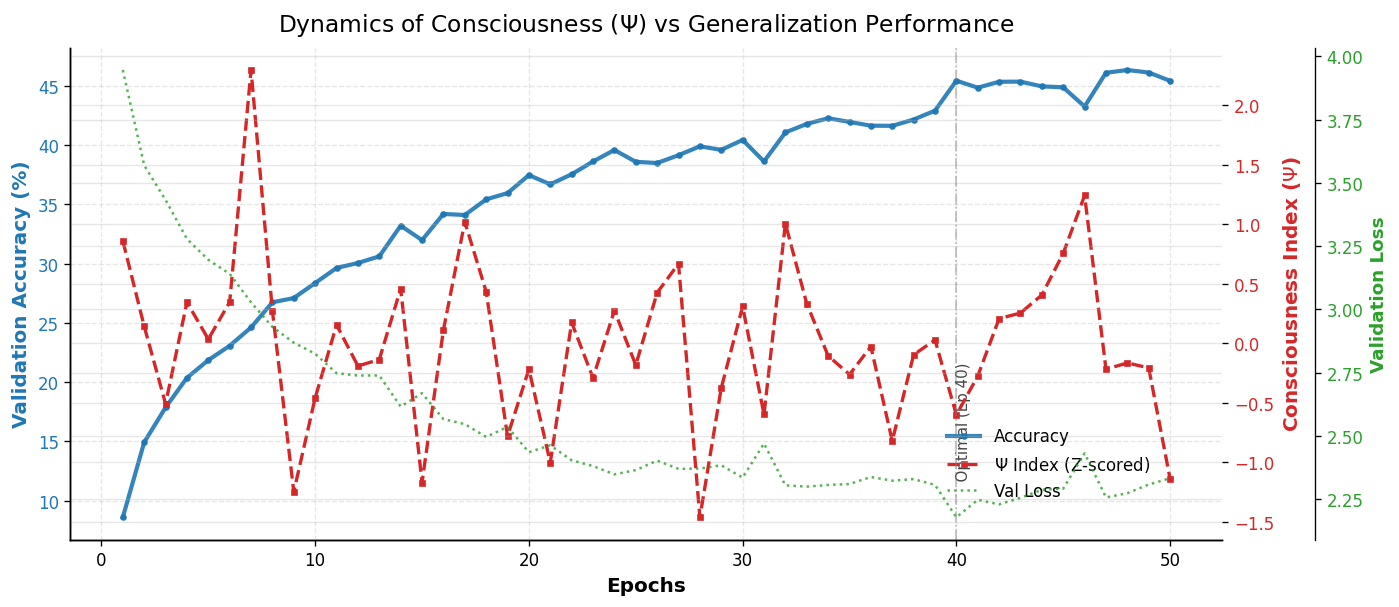

In [24]:
# --- MAIN EXECUTION (UPDATED FOR VGG-16) ---
if __name__ == "__main__":
    # 1. CẤU HÌNH
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Cấu hình H100
    VAL_BATCH_SIZE = 4096 
    TRAIN_BATCH_SIZE = 512 
    EPOCHS = 100          
    PATIENCE = 10         
    LR = 0.01              # <--- SỬA: Giảm LR xuống 0.01 cho VGG

    # 2. DATA LOAD (FAST CIFAR100)
    print("Loading CIFAR-100 directly to H100 VRAM...")
    # Load dataset
    trainset_fast = FastCIFAR100(train=True, device=DEVICE)
    valset_fast = FastCIFAR100(train=False, device=DEVICE)

    # DataLoader (num_workers=0 vì data đã ở trên GPU)
    trainloader = torch.utils.data.DataLoader(trainset_fast, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=0)
    valloader = torch.utils.data.DataLoader(valset_fast, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=0)

# 3. MODEL & OPTIMIZER
    print("Initializing MobileNetV2...")
    
    # MobileNetV2 chuẩn trong torchvision
    model = torchvision.models.mobilenet_v2(num_classes=100).to(DEVICE)
    
    # MobileNet thường cần LR nhỏ hơn ResNet (0.045 hoặc 0.01)
    # Tuy nhiên với SGD momentum thì 0.05 là điểm khởi đầu tốt
    LR = 0.05 
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=4e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5) 
    
    early_stopping = EarlyStopping(patience=PATIENCE, path='best_mobilenet_cifar100.pt')
    
    # --- SETUP HOOK CHO MOBILENET ---
    # Thay thế hàm setup cũ bằng hàm mới này
    activations = setup_mobilenet_hooks(model)
    
    # 4. TRAINING LOOP
    history = []
    print(f"Training started for max {EPOCHS} epochs...")

    for epoch in range(EPOCHS):
        # --- TRAIN ---
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        
        for inputs, targets in trainloader: # inputs/targets đã ở trên GPU
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
        avg_train_loss = train_loss / len(trainloader)
        train_acc = 100. * correct / total

        # --- VALIDATE ---
        model.eval()
        val_loss = 0 
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, targets in valloader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        avg_val_loss = val_loss / len(valloader)
        val_acc = 100. * val_correct / val_total
        
        scheduler.step(avg_val_loss)

        # --- TÍNH PSI ĐA TẦNG (ALGORITHM 1) ---
        # 1. Lấy 1 batch lớn từ Validation
        data_iter = iter(valloader)
        inputs_psi, targets_psi = next(data_iter)
        
        # 2. Forward pass (Kích hoạt Hooks để lấy activations)
        _ = model(inputs_psi) 
        
        # 3. Gom dữ liệu (Dùng hàm gather, hàm này tự động lấy key 'layer1'...'layer4' từ hook VGG)
        multiscale_matrix = gather_multiscale_activations(activations, samples_per_layer=32)
        
        # 4. Adapter (Sắp xếp & Làm mượt)
        # Lưu ý: Với CIFAR-100, nên tăng smooth_window lên 15 để nối liền tín hiệu bị phân mảnh
        cnn_signals = prepare_cnn_activations(multiscale_matrix, targets_psi, smooth_window=15)
        
        # 5. Tính Metrics
        metrics = compute_raw_metrics(cnn_signals)

        # --- LOGGING ---
        log = {
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_acc": val_acc,
            "Heff": metrics["Heff"], 
            "M": metrics["M"],       
            "H_raw": metrics["H_raw"]
        }
        history.append(log)
        
        current_lr = optimizer.param_groups[0]['lr']
        
        # In ra thông số
        print(f"Ep {epoch+1:03d} | Loss:{avg_val_loss:.3f} | Acc:{val_acc:.2f}% | "
              f"Heff:{metrics['Heff']:.2f} | H_raw:{metrics['H_raw']:.3f} | M:{metrics['M']:.3f} | LR:{current_lr}")

        # --- CHECK EARLY STOPPING ---
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    # --- KẾT THÚC LOOP ---
    print("\nTraining Finished. Calculating Standardized Psi (Z-score)...")
    
    # BẮT BUỘC CHẠY HÀM NÀY ĐỂ CÓ CỘT 'Psi'
    df_results = summarize_experiment_results(history) 

    print("\n" + "="*60)
    print(f"{'Epoch':<6} | {'Acc (%)':<8} | {'Hz':<8} | {'Mz':<8} | {'Psi (Std)':<10}")
    print("-" * 60)
    
    for _, row in df_results.iterrows():
        # In ra từng dòng giá trị Psi đã chuẩn hóa
        print(f"{int(row['epoch']):<6d} | {row['val_acc']:<8.2f} | "
              f"{row['Hz']:<8.3f} | {row['Mz']:<8.3f} | {row['Psi']:<10.4f}")
              
    print("="*60 + "\n")
    
    # <--- SỬA: Đổi tên file lưu kết quả
    df_results.to_csv("results_mobilenet_cifar100.csv", index=False)
    
    # Vẽ đồ thị
    plot_final_report(df_results)